https://stat.taiwan.net.tw/ <br>
觀光遊憩據點 ->  單一類別查詢 ->統計方式:年報(Year) ->選擇北部地區(North Area) -> 選擇新竹縣/市

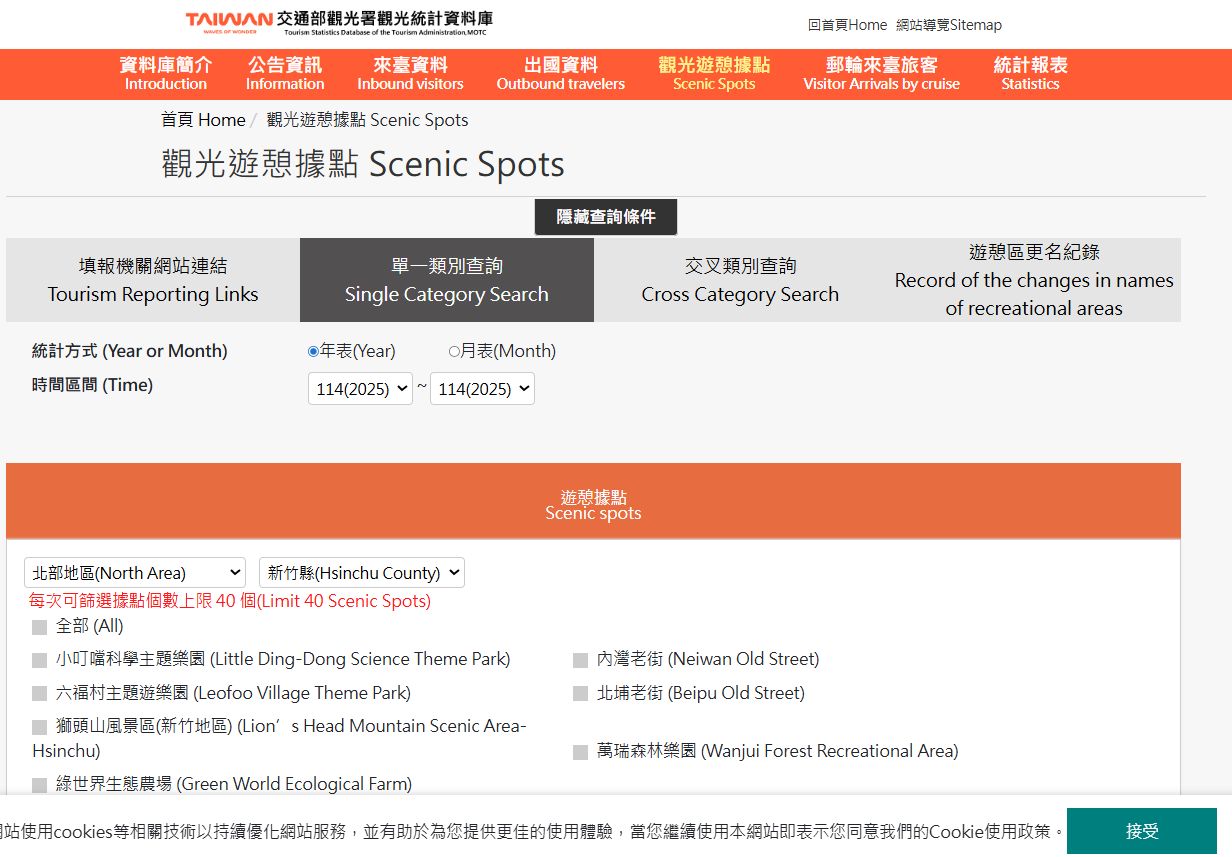

In [97]:
# 掛載Google 雲端硬碟
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
import pandas as pd
import io
import folium
from geopy.geocoders import Nominatim
import time # 確保導入 time 模組以使用 sleep 功能

# 讀取原始檔案

In [69]:
basepath = "/content/drive/MyDrive/del_校驗/新竹縣市2025年旅遊景點觀光人次/"
file1 = "新竹市_觀光遊憩據點按遊憩據點統計.csv"
file2 = "新竹縣_觀光遊憩據點按遊憩據點統計.csv"

In [99]:
# 新竹市
df1 = pd.read_csv(basepath + file1)
df1 = df1.drop(columns=["年度"])
df1 = df1.drop(index=[0,2])
df1 = df1.T
df1 = df1.reset_index()
df1.columns = ["景點名稱", "觀光人次"]
df1
# df1 = df1.T

,景點名稱,觀光人次
0,新竹漁港,2256718
1,新竹公園,3861124
2,新竹城隍廟,0


In [100]:
# 新竹縣
df2 = pd.read_csv(basepath + file2)
df2 = df2.drop(columns=["年度"])
df2 = df2.drop(index=[0,2])
df2 = df2.T
df2 = df2.reset_index()
df2.columns = ["景點名稱", "觀光人次"]
df2

,景點名稱,觀光人次
0,獅頭山風景區(新竹地區),1254720
1,六福村主題遊樂園,1072686
2,小叮噹科學主題樂園,442850
3,萬瑞森林樂園,49032
4,綠世界生態農場,331605
5,北埔老街,961277
6,內灣老街,1595818


In [101]:
# 合併新竹市與新竹縣
df = pd.concat([df1, df2], axis=0)
df = df.reset_index(drop=True)
df

,景點名稱,觀光人次
0,新竹漁港,2256718
1,新竹公園,3861124
2,新竹城隍廟,0
3,獅頭山風景區(新竹地區),1254720
4,六福村主題遊樂園,1072686
5,小叮噹科學主題樂園,442850
6,萬瑞森林樂園,49032
7,綠世界生態農場,331605
8,北埔老街,961277
9,內灣老街,1595818


In [105]:
df.dtypes

,0
景點名稱,object
觀光人次,int64


In [106]:
# 轉換型態為int
df["觀光人次"] = pd.to_numeric(df["觀光人次"]) # 優點：非常強大，可以處理非數字的雜訊（如文字、空格）。
#df["觀光人次"] = df["觀光人次"].astype(int) # 優點：執行速度稍快，語法簡潔。缺點：非常脆弱。如果資料中包含 NaN（空值） 或 非數字文字，它會直接拋出錯誤（Exception）。
df.dtypes

,0
景點名稱,object
觀光人次,int64


# 依照觀光人次進行排序

In [107]:
df_sorted = df.sort_values(by=['觀光人次'], ascending=False)
df_sorted.reset_index(drop=True, inplace=True)
df_sorted

,景點名稱,觀光人次
0,新竹公園,3861124
1,新竹漁港,2256718
2,內灣老街,1595818
3,獅頭山風景區(新竹地區),1254720
4,六福村主題遊樂園,1072686
5,北埔老街,961277
6,小叮噹科學主題樂園,442850
7,綠世界生態農場,331605
8,萬瑞森林樂園,49032
9,新竹城隍廟,0


# 觀光人次出名次

In [108]:
#df["觀光人次"] = pd.to_numeric(df["觀光人次"]
df_sorted["名次"] = df_sorted["觀光人次"].rank(method='min', ascending=False).astype(int)
# df_sorted["名次"] = pd.to_numeric(df_sorted["觀光人次"].astype(int)).rank(method='min', ascending=False).astype(int)
df_sorted

,景點名稱,觀光人次,名次
0,新竹公園,3861124,1
1,新竹漁港,2256718,2
2,內灣老街,1595818,3
3,獅頭山風景區(新竹地區),1254720,4
4,六福村主題遊樂園,1072686,5
5,北埔老街,961277,6
6,小叮噹科學主題樂園,442850,7
7,綠世界生態農場,331605,8
8,萬瑞森林樂園,49032,9
9,新竹城隍廟,0,10


# 取得地址經緯度

In [109]:
 # 使用 geopy 獲取經緯度 (若您已有經緯度欄位可跳過此步)
geolocator = Nominatim(user_agent="hsinchu_explorer", timeout=5)

def geocoder(row):
    try:
        point = geolocator.geocode(row, country_codes = "TW").point
        return pd.Series({'Latitude': point.latitude, 'Longitude': point.longitude})
    except:
        return None

df_sorted[['Latitude', 'Longitude']] = df_sorted.apply(lambda x: geocoder("新竹 "+x['景點名稱']), axis=1)
df_sorted

,景點名稱,觀光人次,名次,Latitude,Longitude
0,新竹公園,3861124,1,24.800557,120.978193
1,新竹漁港,2256718,2,24.847662,120.921975
2,內灣老街,1595818,3,NaN,NaN
3,獅頭山風景區(新竹地區),1254720,4,NaN,NaN
4,六福村主題遊樂園,1072686,5,24.820225,121.181606
5,北埔老街,961277,6,24.700682,121.055678
6,小叮噹科學主題樂園,442850,7,24.870290,120.978657
7,綠世界生態農場,331605,8,24.712765,121.070445
8,萬瑞森林樂園,49032,9,24.702671,121.132805
9,新竹城隍廟,0,10,24.804356,120.966065


In [110]:
# 獅頭山風景區(新竹地區)、內灣老街無法取得經緯度，所以進行名稱轉換

df_sorted.loc[df_sorted["景點名稱"] == "獅頭山風景區(新竹地區)", "景點名稱"] = "獅山遊客中心"
# df_sorted = df_sorted["景點名稱"].replace("獅頭山風景區(新竹地區)", "獅頭山風景區")

df_sorted.loc[df_sorted["景點名稱"] == "內灣老街", "景點名稱"] = "內灣車站"
df_sorted

,景點名稱,觀光人次,名次,Latitude,Longitude
0,新竹公園,3861124,1,24.800557,120.978193
1,新竹漁港,2256718,2,24.847662,120.921975
2,內灣車站,1595818,3,NaN,NaN
3,獅山遊客中心,1254720,4,NaN,NaN
4,六福村主題遊樂園,1072686,5,24.820225,121.181606
5,北埔老街,961277,6,24.700682,121.055678
6,小叮噹科學主題樂園,442850,7,24.870290,120.978657
7,綠世界生態農場,331605,8,24.712765,121.070445
8,萬瑞森林樂園,49032,9,24.702671,121.132805
9,新竹城隍廟,0,10,24.804356,120.966065


In [111]:
 # 使用 geopy 獲取經緯度 (若您已有經緯度欄位可跳過此步)
geolocator = Nominatim(user_agent="hsinchu_explorer", timeout=5)

def geocoder(row):
    try:
        point = geolocator.geocode(row, country_codes = "TW").point
        return pd.Series({'Latitude': point.latitude, 'Longitude': point.longitude})
    except:
        return None

df_sorted[['Latitude', 'Longitude']] = df_sorted.apply(lambda x: geocoder("新竹 "+x['景點名稱']), axis=1)
df_sorted

,景點名稱,觀光人次,名次,Latitude,Longitude
0,新竹公園,3861124,1,24.800557,120.978193
1,新竹漁港,2256718,2,24.847662,120.921975
2,內灣車站,1595818,3,24.705335,121.182538
3,獅山遊客中心,1254720,4,24.655044,121.024424
4,六福村主題遊樂園,1072686,5,24.820225,121.181606
5,北埔老街,961277,6,24.700682,121.055678
6,小叮噹科學主題樂園,442850,7,24.870290,120.978657
7,綠世界生態農場,331605,8,24.712765,121.070445
8,萬瑞森林樂園,49032,9,24.702671,121.132805
9,新竹城隍廟,0,10,24.804356,120.966065


# Folium底圖

In [112]:
def generate_hsinchu_map(df):
    # 初始化地圖 (中心設在新竹)
    m = folium.Map(location=[24.8047, 120.9714], zoom_start=11)

    for index, row in df.iterrows():
        lat, lon = row['Latitude'], row['Longitude']
        if pd.notnull(lat) and pd.notnull(lon):
            # 設定顏色：前三名用金色，其餘用藍色
            color = '#FFD700' if row['名次'] <= 3 else '#3186cc'

            # A. 圓圈標記 (代表觀光人次規模)
            radius = (row['觀光人次'] ** 0.5) / 40
            folium.CircleMarker(
                location=[lat, lon],
                radius=max(radius, 8),
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.6,
                popup=f"<b>{row['景點名稱']}</b><br>名次：{row['名次']}<br>人次：{row['觀光人次']:,}"
            ).add_to(m)

            # B. 名次標籤 (顯示數字)
            folium.map.Marker(
                [lat, lon],
                icon=folium.DivIcon(
                    html=f"""<div style="font-family: Arial; color: white; background: black;
                          border-radius: 50%; width: 22px; height: 22px; display: flex;
                          align-items: center; justify-content: center; font-size: 9pt;
                          font-weight: bold; border: 2px solid {color};">{row['名次']}</div>""",
                    icon_anchor=(11, 11)
                )
            ).add_to(m)

    output_file = 'hsinchu_tourism_map.html'
    m.save('hsinchu_tourism_map.html')
    print(f"\n互動式地圖已生成：{output_file}")

In [113]:
  # 執行生成
generate_hsinchu_map(df_sorted)


互動式地圖已生成：hsinchu_tourism_map.html


# Google Map 底圖

In [114]:
def generate_hsinchu_google_map(df):
    # 初始化地圖
    # 使用 Google Maps 街道圖磚 (Tiles)
    # 常用網址格式:
    # 街道圖: http://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}
    # 衛星圖: http://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}
    # 混合圖: http://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}

    google_map_tiles = "http://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}"

    m = folium.Map(
        location=[24.8047, 120.9714],
        zoom_start=11,
        tiles=google_map_tiles,
        attr='Google' # 必須註明屬性來源
    )

    for index, row in df.iterrows():
        lat, lon = row['Latitude'], row['Longitude']
        if pd.notnull(lat) and pd.notnull(lon):
            # 前三名用紅色突出顯示，其餘用藍色
            color = '#FF0000' if row['名次'] <= 3 else '#1E90FF'

            # A. 圓圈標記 (代表觀光人次規模)
            radius = (row['觀光人次'] ** 0.5) / 40
            folium.CircleMarker(
                location=[lat, lon],
                radius=max(radius, 10),
                color=color,
                weight=2,
                fill=True,
                fill_color=color,
                fill_opacity=0.4,
                popup=f"<b>{row['景點名稱']}</b><br>名次：{row['名次']}<br>人次：{row['觀光人次']:,}"
            ).add_to(m)

            # B. 名次標籤 (顯示數字)
            folium.map.Marker(
                [lat, lon],
                icon=folium.DivIcon(
                    html=f"""<div style="font-family: Arial; color: white; background: {color};
                          border-radius: 50%; width: 24px; height: 24px; display: flex;
                          align-items: center; justify-content: center; font-size: 10pt;
                          font-weight: bold; border: 2px solid white; box-shadow: 2px 2px 5px rgba(0,0,0,0.3);">
                          {row['名次']}</div>""",
                    icon_anchor=(12, 12)
                )
            ).add_to(m)

    output_file = 'hsinchu_google_map.html'
    m.save(output_file)
    print(f"\nGoogle 地圖底圖已生成：{output_file}")

In [115]:
# 執行生成
generate_hsinchu_google_map(df_sorted)


Google 地圖底圖已生成：hsinchu_google_map.html
